## 1. Setup do ambiente

Instala o `pysus`, que baixa e converte os
arquivos do DATASUS.


In [99]:
!pip install -q pysus

import os
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

print("[INFO] Ambiente de trabalho configurado.")

[INFO] Ambiente de trabalho configurado.


---
## 2. Dicionário de dados

A célula abaixo grava o arquivo `sinan_dic.py` no ambiente do Colab.

Transcrito do **Dicionário de Dados SINAN NET 5.1**

In [100]:
%%writefile sinan_dic.py
"""
Dicionário de dados — SINAN / Violência Interpessoal e Autoprovocada
"""

YES_NO = {"1": "Sim", "2": "Não", "9": "Ignorado"}
YES_NO_NA = {"1": "Sim", "2": "Não", "8": "Não se aplica", "9": "Ignorado"}

LABELS = {
    # --- notificação ---
    "SG_UF_NOT": "UF de notificação",

    # --- vítima ---
    "NU_IDADE_N": "Idade (codificada)",
    "CS_SEXO": "Sexo",
    "CS_RACA": "Raça/cor",
    "CS_ESCOL_N": "Escolaridade",
    "SIT_CONJUG": "Situação conjugal",

    # --- residência ---
    "SG_UF": "UF de residência",

    # --- deficiência e transtorno ---
    "DEF_TRANS": "Possui deficiência ou transtorno",
    "DEF_FISICA": "Deficiência física",
    "DEF_MENTAL": "Deficiência intelectual",
    "DEF_VISUAL": "Deficiência visual",
    "DEF_AUDITI": "Deficiência auditiva",
    "TRAN_MENT": "Transtorno mental",
    "TRAN_COMP": "Transtorno de comportamento",
    "DEF_OUT": "Outras deficiências ou síndromes",

    # --- ocorrência ---
    "SG_UF_OCOR": "UF de ocorrência",
    "LOCAL_OCOR": "Local de ocorrência",

    # --- caracterização da violência ---
    "OUT_VEZES": "Violência de repetição",
    "LES_AUTOP": "Lesão autoprovocada",
    "VIOL_MOTIV": "Violência motivada por",
    "VIOL_FISIC": "Violência física",
    "VIOL_PSICO": "Violência psicológica/moral",
    "VIOL_TORT": "Tortura",
    "VIOL_SEXU": "Violência sexual",
    "VIOL_TRAF": "Tráfico de seres humanos",
    "VIOL_FINAN": "Violência financeira/econômica",
    "VIOL_NEGLI": "Negligência/abandono",
    "VIOL_LEGAL": "Intervenção legal",
    "VIOL_OUTR": "Outro tipo de violência",

    # --- meio de agressão ---
    "AG_FORCA": "Meio — força corporal/espancamento",
    "AG_ENFOR": "Meio — enforcamento",
    "AG_OBJETO": "Meio — objeto contundente",
    "AG_CORTE": "Meio — objeto perfurocortante",
    "AG_QUENTE": "Meio — substância/objeto quente",
    "AG_ENVEN": "Meio — envenenamento/intoxicação",
    "AG_FOGO": "Meio — arma de fogo",
    "AG_AMEACA": "Meio — ameaça",
    "AG_OUTROS": "Meio — outro",

    # --- provável autor ---
    "NUM_ENVOLV": "Número de envolvidos",
    "REL_PAI": "Autor — pai",
    "REL_MAE": "Autor — mãe",
    "REL_PAD": "Autor — padrasto",
    "REL_MAD": "Autor — madrasta",
    "REL_CONJ": "Autor — cônjuge",
    "REL_EXCON": "Autor — ex-cônjuge",
    "REL_NAMO": "Autor — namorado(a)",
    "REL_EXNAM": "Autor — ex-namorado(a)",
    "REL_FILHO": "Autor — filho(a)",
    "REL_IRMAO": "Autor — irmão(ã)",
    "REL_CONHEC": "Autor — amigo/conhecido",
    "REL_DESCO": "Autor — desconhecido",
    "REL_CUIDA": "Autor — cuidador",
    "REL_PATRAO": "Autor — patrão/chefe",
    "REL_INST": "Autor — relação institucional",
    "REL_POL": "Autor — policial/agente da lei",
    "REL_PROPRI": "Autor — a própria pessoa",
    "REL_OUTROS": "Autor — outros",
    "AUTOR_SEXO": "Sexo do provável autor",
    "AUTOR_ALCO": "Suspeita de uso de álcool pelo autor",
}

CATEGORIES = {
    "CS_SEXO": {"M": "Masculino", "F": "Feminino", "I": "Ignorado"},

    "CS_RACA": {
        "1": "Branca", "2": "Preta", "3": "Amarela",
        "4": "Parda", "5": "Indígena", "9": "Ignorado",
    },


    "CS_ESCOL_N": {
        "0": "Analfabeto",
        "1": "1ª a 4ª série incompleta do EF",
        "2": "4ª série completa do EF",
        "3": "5ª a 8ª série incompleta do EF",
        "4": "Ensino fundamental completo",
        "5": "Ensino médio incompleto",
        "6": "Ensino médio completo",
        "7": "Educação superior incompleta",
        "8": "Educação superior completa",
        "9": "Ignorado",
        "10": "Não se aplica",
    },

    "SIT_CONJUG": {
        "1": "Solteiro", "2": "Casado/união consensual", "3": "Viúvo",
        "4": "Separado", "8": "Não se aplica", "9": "Ignorado",
    },

    "LOCAL_OCOR": {
        "01": "Residência", "02": "Habitação coletiva", "03": "Escola",
        "04": "Local de prática esportiva", "05": "Bar ou similar",
        "06": "Via pública", "07": "Comércio/serviços",
        "08": "Indústrias/construção", "09": "Outro", "99": "Ignorado",
    },

    "VIOL_MOTIV": {
        "01": "Sexismo",
        "02": "Homofobia/lesbofobia/bifobia/transfobia",
        "03": "Racismo",
        "04": "Intolerância religiosa",
        "05": "Xenofobia",
        "06": "Conflito geracional",
        "07": "Situação de rua",
        "08": "Deficiência",
        "09": "Outros",
        "88": "Não se aplica",
        "99": "Ignorado",
    },

    "NUM_ENVOLV": {"1": "Um", "2": "Dois ou mais", "9": "Ignorado"},

    "AUTOR_SEXO": {
        "1": "Masculino", "2": "Feminino",
        "3": "Ambos os sexos", "9": "Ignorado",
    },
}

# Campos Sim/Não/Ignorado
_YES_NO_FIELDS = [
    "OUT_VEZES", "DEF_TRANS",
    "VIOL_FISIC", "VIOL_PSICO", "VIOL_TORT", "VIOL_SEXU", "VIOL_TRAF",
    "VIOL_FINAN", "VIOL_NEGLI", "VIOL_LEGAL", "VIOL_OUTR",
    "AG_FORCA", "AG_ENFOR", "AG_OBJETO", "AG_CORTE", "AG_QUENTE",
    "AG_ENVEN", "AG_FOGO", "AG_AMEACA", "AG_OUTROS",
    "REL_PAI", "REL_MAE", "REL_PAD", "REL_MAD", "REL_CONJ", "REL_EXCON",
    "REL_NAMO", "REL_EXNAM", "REL_FILHO", "REL_IRMAO", "REL_CONHEC",
    "REL_DESCO", "REL_CUIDA", "REL_PATRAO", "REL_INST", "REL_POL","REL_PROPRI",
    "REL_OUTROS", "AUTOR_ALCO",
]

# Campos que aceitam "Não se aplica"
_YES_NO_NA_FIELDS = [
    "LES_AUTOP",
    "DEF_FISICA", "DEF_MENTAL", "DEF_VISUAL", "DEF_AUDITI",
    "TRAN_MENT", "TRAN_COMP", "DEF_OUT",
]

for _f in _YES_NO_FIELDS:
    CATEGORIES.setdefault(_f, dict(YES_NO))
for _f in _YES_NO_NA_FIELDS:
    CATEGORIES.setdefault(_f, dict(YES_NO_NA))

# Códigos IBGE de UF
UF_CODE = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA",
    "16": "AP", "17": "TO",
    "21": "MA", "22": "PI", "23": "CE", "24": "RN", "25": "PB",
    "26": "PE", "27": "AL", "28": "SE", "29": "BA",
    "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS",
    "50": "MS", "51": "MT", "52": "GO", "53": "DF",
}

UF_NAME = {
    "AC": "Acre", "AL": "Alagoas", "AP": "Amapá", "AM": "Amazonas",
    "BA": "Bahia", "CE": "Ceará", "DF": "Distrito Federal",
    "ES": "Espírito Santo", "GO": "Goiás", "MA": "Maranhão",
    "MT": "Mato Grosso", "MS": "Mato Grosso do Sul", "MG": "Minas Gerais",
    "PA": "Pará", "PB": "Paraíba", "PR": "Paraná", "PE": "Pernambuco",
    "PI": "Piauí", "RJ": "Rio de Janeiro", "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul", "RO": "Rondônia", "RR": "Roraima",
    "SC": "Santa Catarina", "SP": "São Paulo", "SE": "Sergipe",
    "TO": "Tocantins",
}


ATRIBUTOS_PROTEGIDOS = ["CS_RACA", "CS_SEXO"]



Overwriting sinan_dic.py


---
## 3. Configuração

Onde é decidido a idade mínima, o alvo e as colunas relevantes.

In [101]:
YEAR = 2024

MINIMAL_AGE = 60
TARGET = "OUT_VEZES" # Violência de repetição?

# Colunas para processamento
COLUMNS = [
    # --- identificação e alvo ---
    "NU_IDADE_N",
    "OUT_VEZES",
    "SG_UF_OCOR",
    "SG_UF_NOT"
    ,"SG_UF",

    # --- perfil da vítima ---
    "CS_SEXO",
    "CS_RACA",
    "CS_ESCOL_N",
    "SIT_CONJUG",

    # --- deficiência e transtorno ---
    "DEF_TRANS",
    "DEF_FISICA",
    "DEF_MENTAL",
    "DEF_VISUAL",
    "DEF_AUDITI",
    "TRAN_MENT",
    "TRAN_COMP",
    "DEF_OUT",

    # --- contexto da ocorrência ---
    "LOCAL_OCOR",
    "VIOL_MOTIV",
    "LES_AUTOP",

    # --- tipo de violência ---
    "VIOL_FISIC",
    "VIOL_PSICO",
    "VIOL_TORT",
    "VIOL_SEXU",
    "VIOL_TRAF",
    "VIOL_FINAN",
    "VIOL_NEGLI",
    "VIOL_LEGAL",
    "VIOL_OUTR",

    # --- meio de agressão ---
    "AG_FORCA",
    "AG_AMEACA",
    "AG_OBJETO",
    "AG_CORTE",
    "AG_QUENTE",
    "AG_ENFOR",
    "AG_ENVEN",
    "AG_FOGO",
    "AG_OUTROS",

    # --- provável autor ---
    "NUM_ENVOLV",
    "AUTOR_SEXO",
    "AUTOR_ALCO",
    "REL_FILHO",
    "REL_CONJ",
    "REL_EXCON",
    "REL_CUIDA",
    "REL_PAI",
    "REL_MAE",
    "REL_IRMAO",
    "REL_CONHEC",
    "REL_DESCO",
    "REL_INST",
    "REL_PATRAO",
    "REL_POL",
        "REL_PROPRI",
    "REL_NAMO",
    "REL_EXNAM",
    "REL_PAD",
    "REL_MAD",
    "REL_OUTROS",
]

COL_AGE = "NU_IDADE_N"

# Organizando colunas e eliminando duplicatas
COLUMNS = list(dict.fromkeys([COL_AGE, TARGET] + COLUMNS))

# print(f"[DEBUG] Ano: {YEAR} | {len(COLUMNS)} colunas selecionadas")

In [102]:
# Declaração de funções

def normalize_code(value):
    """Normalizando valores do .parquet, exemplo: '1', ' 1', 1 ou 1.0 tem que virar o mesmo valor"""
    if pd.isna(value):
        return None
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text or None


---
## 4. Download dos microdados

Via FTP, no DATASUS, em `/dissemin/publicos/SINAN/DADOS/FINAIS/VIOLBR<ano>`. Baixado em .dbc e convertido para .parquet para melhor manuseamento dos dados.


In [103]:
from pysus import sinan
import pyarrow.parquet as parq

# Download

print(f"[INFO] Iniciando download de SINAL/VIOL edição {YEAR}.")

paths = sinan(disease="VIOL", year=YEAR)
filename = str(paths[0]) if isinstance(paths, list) else str(paths)

print(f"[INFO] Download concluído com sucesso.")

# Validando arquivo
file = parq.ParquetFile(filename)

file_cols = list(file.schema_arrow.names)

missing = [c for c in COLUMNS if c not in file_cols]
if missing:
    print(f"[AVISO] ATENÇÃO — não existem neste arquivo: {missing}")
    COLUMNS = [c for c in COLUMNS if c in file_cols]

raw_data = pd.read_parquet(filename, columns=COLUMNS)

# print(f"[DEBUG] Carregado: {raw_data.shape[0]:,} linhas x {raw_data.shape[1]} colunas")

raw_data.head(1)


[INFO] Iniciando download de SINAL/VIOL edição 2024.


VIOLBR24.parquet: 0.00B [00:00, ?B/s]


[INFO] Download concluído com sucesso.


,NU_IDADE_N,OUT_VEZES,SG_UF_OCOR,SG_UF_NOT,SG_UF,CS_SEXO,CS_RACA,CS_ESCOL_N,SIT_CONJUG,DEF_TRANS,DEF_FISICA,DEF_MENTAL,DEF_VISUAL,DEF_AUDITI,TRAN_MENT,TRAN_COMP,DEF_OUT,LOCAL_OCOR,VIOL_MOTIV,LES_AUTOP,VIOL_FISIC,VIOL_PSICO,VIOL_TORT,VIOL_SEXU,VIOL_TRAF,VIOL_FINAN,VIOL_NEGLI,VIOL_LEGAL,VIOL_OUTR,AG_FORCA,AG_AMEACA,AG_OBJETO,AG_CORTE,AG_QUENTE,AG_ENFOR,AG_ENVEN,AG_FOGO,AG_OUTROS,NUM_ENVOLV,AUTOR_SEXO,AUTOR_ALCO,REL_FILHO,REL_CONJ,REL_EXCON,REL_CUIDA,REL_PAI,REL_MAE,REL_IRMAO,REL_CONHEC,REL_DESCO,REL_INST,REL_PATRAO,REL_POL,REL_PROPRI,REL_NAMO,REL_EXNAM,REL_PAD,REL_MAD,REL_OUTROS
0,4033,1,52,52,52,F,4,09,2,2,8,8,8,8,8,8,8,01,09,2,2,1,2,2,2,2,2,2,2,2,1,2,2,2,2,2,2,2,1,1,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


---
## 5. Filtrar vítimas 60+

Decodificar idade e filtrar apenas pessoas com 60+

### Dicionário

| 1º dígito | Unidade |
|---|---|
| 1 | horas |
| 2 | dias |
| 3 | meses |
| 4 | anos |


In [104]:
age_encoded = pd.to_numeric(raw_data[COL_AGE], errors="coerce")
unit = age_encoded // 1000
quantity = age_encoded % 1000

# Só é idade de interesse quando a unidade é anos
raw_data["Idade"] = quantity.where(unit == 4)

# Filtrando apenas idosos
elderly = raw_data[raw_data["Idade"] >= MINIMAL_AGE].copy()
raw_data["Idade"] = raw_data["Idade"].astype("Int64")

print(f"Total de notificações no ano : {len(raw_data):,}")
print(f"Vítimas {MINIMAL_AGE}+                  : {len(elderly):,}")
print(f"Proporção                    : {len(elderly)/len(raw_data):.1%}")
print(f"\nIdade idosos - mín: {elderly['Idade'].min():.0f} | máx: {elderly['Idade'].max():.0f}")

if elderly.empty:
    raise SystemExit(
        "[ERRO] Nenhum registro encontrado. Parando o programa."
    )


Total de notificações no ano : 616,548
Vítimas 60+                  : 42,176
Proporção                    : 6.8%

Idade idosos - mín: 60 | máx: 130


---
## 6. Validade do alvo

Alvo: `OUT_VEZES`

Perda pode ser até 30%


In [105]:
counting = elderly[TARGET].value_counts(dropna=False)
portion = elderly[TARGET].value_counts(dropna=False, normalize=True)
codes = elderly[TARGET].map(normalize_code)

# Calculando valores e perda (ignorado e nulos)
loss = codes.isna().sum() + (codes == "9").sum()
yes = (codes == "1").sum()
no = (codes == "2").sum()
useful = yes + no

print(f"\nTotal {MINIMAL_AGE}+  : {len(elderly):,}")
print(f"Perda      : {loss:,}  ({loss/len(elderly):.1%})")
print(f"Casos úteis: {useful:,}")

if useful:
    print(f"  Sim: {yes:,} ({yes/useful:.2%})")
    print(f"  Não: {no:,} ({no/useful:.2%})")

    print(f"Teto de variáveis: {min(yes, no)//10}")

    if loss / len(elderly) < 0.30:
        print("\n[INFO] Perda abaixo de 30%, seguir com o alvo atual.")
    else:
        print("\n[INFO] Revisar projeto.")


Total 60+  : 42,176
Perda      : 11,943  (28.3%)
Casos úteis: 30,233
  Sim: 15,426 (51.02%)
  Não: 14,807 (48.98%)
Teto de variáveis: 1480

[INFO] Perda abaixo de 30%, seguir com o alvo atual.


---
## 7. Traduzir códigos e nomes

Traduzindo valores e colunas de acordo com o dicionário

In [106]:
def decode_uf(series, to="sigla"):
    """Aceita código IBGE ou sigla, dai devolve sigla ou nome por extenso."""
    values = series.map(normalize_code)
    acronym = values.map(
        lambda v: v if v in UF_CODE.values() else UF_CODE.get(v.zfill(2))
        if v else None
    )
    return acronym if to == "sigla" else acronym.map(UF_NAME)

for col in ["SG_UF_NOT", "SG_UF_OCOR", "SG_UF"]:
    if col in elderly.columns:
        elderly[col] = decode_uf(elderly[col])


print(elderly["SG_UF_NOT"].value_counts().head(27))

SG_UF_NOT
SP    9181
RJ    5784
PR    3971
CE    3959
MG    3696
PE    2948
RS    2546
BA    1438
MS    1338
ES    1291
SC    1240
GO     927
TO     469
PA     407
DF     391
AL     351
AM     327
MA     309
PI     285
SE     279
PB     251
RN     251
MT     217
RO     120
AC      92
RR      82
AP      26
Name: count, dtype: int64


In [115]:
def expand_map(dic):
    """Fazer todos os campos serem lidos se estiverem escritos com 1 digito ou 2 digitos"""
    expanded = {}
    for key, value in dic.items():
        expanded[key] = value
        expanded.setdefault(key.lstrip("0") or "0", value)
        expanded.setdefault(key.zfill(2), value)
    return expanded

data_translated = elderly.copy()

for col, dic in CATEGORIES.items():
    if col not in data_translated.columns:
        continue

    col_codes = data_translated[col].map(normalize_code)
    translated = col_codes.map(expand_map(dic))

    # Avisa caso tiver algum campo sem tradução
    orphans = col_codes[translated.isna() & col_codes.notna()].value_counts()
    if not orphans.empty:
        print(f"[AVISO] {col}: códigos sem tradução {orphans.to_dict()}")

    data_translated[col] = translated

data_translated = data_translated.drop(columns=["UF de ocorrência","UF de residência"], errors="ignore")

# Deixa só a idade traduzida
data_translated = data_translated.drop(columns=[COL_AGE], errors="ignore")

data_translated = data_translated.rename(
    columns={c: LABELS[c] for c in data_translated.columns if c in LABELS}
)

# Reordenando
cols_order = ["Violência de repetição", "Idade", "Sexo", "Raça/cor", "Escolaridade","Situação conjugal","UF de notificação", "Local de ocorrência"]

ordem = cols_order + [c for c in data_translated.columns if c not in cols_order]
data_translated = data_translated[ordem]

print(f"\n{data_translated.shape[0]:,} linhas x {data_translated.shape[1]} colunas")
data_translated.head()


42,176 linhas x 59 colunas


,Violência de repetição,Idade,Sexo,Raça/cor,Escolaridade,Situação conjugal,UF de notificação,Local de ocorrência,UF de ocorrência,UF de residência,Possui deficiência ou transtorno,Deficiência física,Deficiência intelectual,Deficiência visual,Deficiência auditiva,Transtorno mental,Transtorno de comportamento,Outras deficiências ou síndromes,Violência motivada por,Lesão autoprovocada,Violência física,Violência psicológica/moral,Tortura,Violência sexual,Tráfico de seres humanos,Violência financeira/econômica,Negligência/abandono,Intervenção legal,Outro tipo de violência,Meio — força corporal/espancamento,Meio — ameaça,Meio — objeto contundente,Meio — objeto perfurocortante,Meio — substância/objeto quente,Meio — enforcamento,Meio — envenenamento/intoxicação,Meio — arma de fogo,Meio — outro,Número de envolvidos,Sexo do provável autor,Suspeita de uso de álcool pelo autor,Autor — filho(a),Autor — cônjuge,Autor — ex-cônjuge,Autor — cuidador,Autor — pai,Autor — mãe,Autor — irmão(ã),Autor — amigo/conhecido,Autor — desconhecido,Autor — relação institucional,Autor — patrão/chefe,Autor — policial/agente da lei,Autor — a própria pessoa,Autor — namorado(a),Autor — ex-namorado(a),Autor — padrasto,Autor — madrasta,Autor — outros
66,Não,61.0,Masculino,Parda,4ª série completa do EF,Casado/união consensual,SP,Residência,SP,SP,Sim,Sim,Não,Não,Não,Não,Não,Não,Outros,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Um,Feminino,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não
67,Não,61.0,Masculino,Parda,Ensino fundamental completo,Casado/união consensual,SP,Residência,SP,SP,Sim,Sim,Não,Não,Não,Não,Não,Não,Outros,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Um,Masculino,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não
114,Sim,61.0,Feminino,Branca,Ensino médio completo,Solteiro,PR,Residência,PR,PR,Não,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Ignorado,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Um,Feminino,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não
115,Sim,61.0,Feminino,Branca,Ensino médio completo,Solteiro,PR,Residência,PR,PR,Sim,Não,Não,Não,Não,Sim,Sim,Não,Ignorado,Não,Sim,Sim,Não,Não,Não,Não,Sim,Não,Não,Não,Sim,Não,Não,Não,Não,Sim,Sim,Não,NaN,Feminino,Sim,Sim,Ignorado,Ignorado,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não
163,Sim,69.0,Masculino,Branca,Ensino médio completo,Casado/união consensual,SP,Via pública,SP,SP,Não,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Conflito geracional,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Sim,Não,Não,Não,Não,Não,Não,Não,Um,Masculino,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não


---
## 8. Resumo das variavéis

Tabela das variavéis, ordenadas por % de ignorados



In [119]:
resume = []
for col in elderly.columns:
    if col == "Idade":
        continue
    col_codes = elderly[col].map(normalize_code)
    n = len(col_codes)
    resume.append({
        "campo": col,
        "nome": LABELS.get(col, ""),
        "nulo %": round(col_codes.isna().mean() * 100, 1),
        "ignorado %": round(col_codes.isin(["9", "99"]).mean() * 100, 1),
        "n categorias": col_codes.nunique(),
    })

resume = pd.DataFrame(resume).sort_values("ignorado %", ascending=False).reset_index(drop=True)
resume

,campo,nome,nulo %,ignorado %,n categorias
0,VIOL_MOTIV,Violência motivada por,0.6,31.1,11
1,AUTOR_ALCO,Suspeita de uso de álcool pelo autor,1.7,29.3,3
2,OUT_VEZES,Violência de repetição,0.9,27.4,3
3,SIT_CONJUG,Situação conjugal,2.1,25.1,6
4,DEF_TRANS,Possui deficiência ou transtorno,0.8,21.6,3
5,AUTOR_SEXO,Sexo do provável autor,1.0,16.1,4
6,LOCAL_OCOR,Local de ocorrência,0.0,11.8,10
7,NUM_ENVOLV,Número de envolvidos,1.1,11.8,3
8,REL_OUTROS,Autor — outros,4.8,6.7,3
9,REL_IRMAO,Autor — irmão(ã),5.0,6.4,3


---
## 9. Exportação

Planilha excel com os dados traduzidos

In [109]:
from google.colab import files

NUM_SAMPLE = 500   # None para exportar tudo

if NUM_SAMPLE:
    output = data_translated.sample(n=min(NUM_SAMPLE, len(data_translated)), random_state=42)
    name = f"sinan_idosos_{YEAR}_amostra{NUM_SAMPLE}.xlsx"
else:
    output = data_translated
    name = f"sinan_idosos_{YEAR}_completo.xlsx"

# hardlimit pro excel não travar
if len(output) > 1_000_000:
    name = name.replace(".xlsx", ".csv")
    output.to_csv(name, index=False, sep=";", encoding="utf-8-sig")
else:
    output.to_excel(name, index=False)

print(f"Gerado: {name} ({len(output):,} linhas)")

# Baixa o arquivo
files.download(name)

Gerado: sinan_idosos_2024_amostra500.xlsx  (500 linhas)


---
## 10. EDA

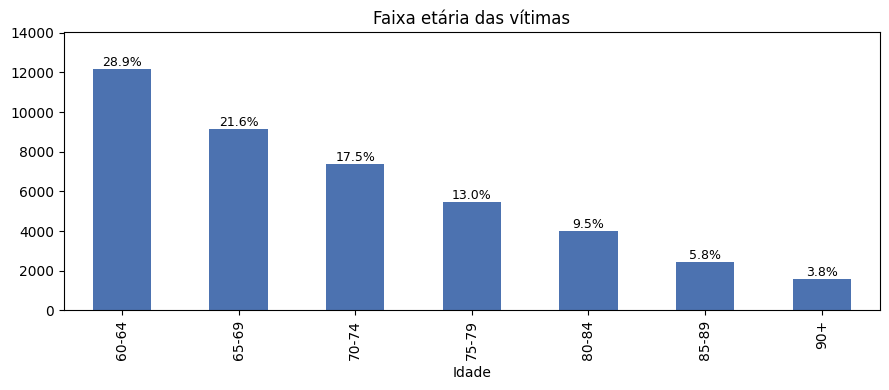

In [111]:
import matplotlib.pyplot as plt

# 1. Distribuição etária

bins = [60, 65, 70, 75, 80, 85, 90, 120]
labels = ["60-64", "65-69", "70-74", "75-79", "80-84", "85-89", "90+"]

counting = pd.cut(
    elderly["Idade"], bins=bins, labels=labels, right=False
).value_counts().sort_index()

percentage = counting / counting.sum() * 100

graph = counting.plot(kind="bar", figsize=(9, 4), color="#4C72B0",
                   title="Faixa etária das vítimas")

for i, (v, p) in enumerate(zip(counting, percentage)):
    graph.text(i, v, f"{p:.1f}%", ha="center", va="bottom", fontsize=9)

graph.set_ylim(0, counting.max() * 1.15)
plt.tight_layout()

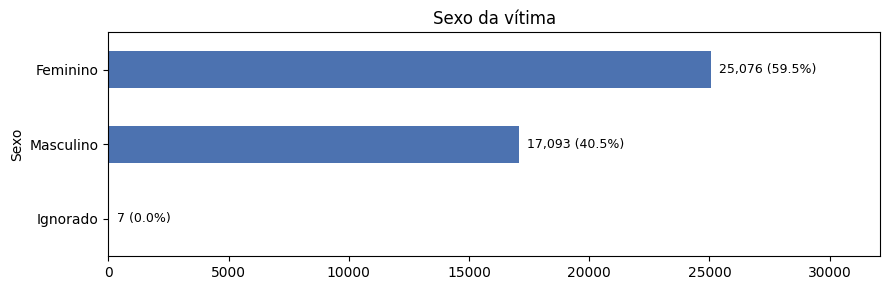

In [112]:
# 2. Sexo da vítima

counting = data_translated["Sexo"].value_counts().sort_values()
percentage = counting / counting.sum() * 100

graph = counting.plot(kind="barh", figsize=(9, 3), color="#4C72B0",
                   title="Sexo da vítima")

for i, (v, p) in enumerate(zip(counting, percentage)):
    graph.text(v, i, f"  {v:,} ({p:.1f}%)", va="center", fontsize=9)

graph.set_xlim(0, counting.max() * 1.28)
plt.tight_layout()

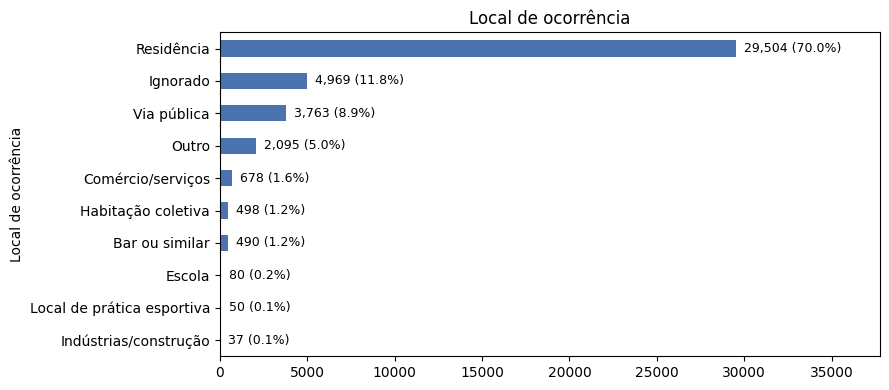

In [130]:
# 3. Local de ocorrência



counting = data_translated["Local de ocorrência"].value_counts().sort_values()
percentage = counting / counting.sum() * 100

graph = counting.plot(kind="barh", figsize=(9, 4), color="#4C72B0",
                   title="Local de ocorrência")

for i, (v, p) in enumerate(zip(counting, percentage)):
    graph.text(v, i, f"  {v:,} ({p:.1f}%)", va="center", fontsize=9)

graph.set_xlim(0, counting.max() * 1.28)
plt.tight_layout()

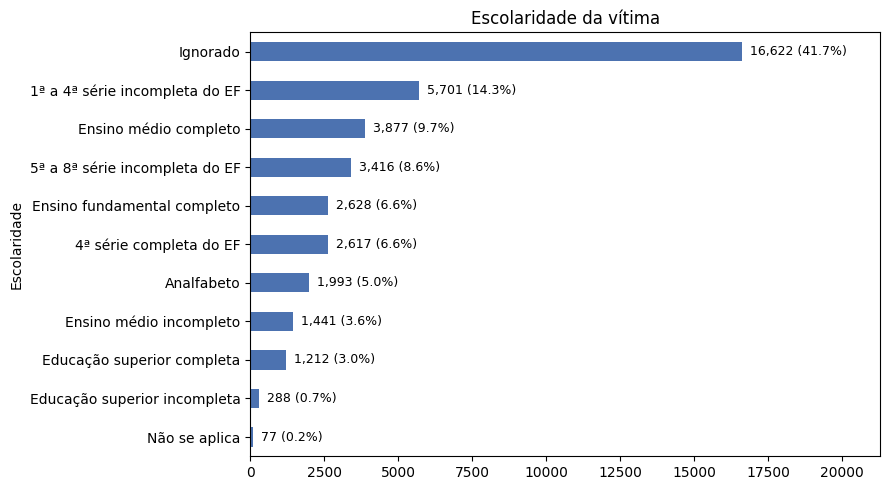

In [121]:
# 4. Escolaridade

counting = data_translated["Escolaridade"].value_counts().sort_values()
percentage = counting / counting.sum() * 100

graph = counting.plot(kind="barh", figsize=(9, 5), color="#4C72B0",
                   title="Escolaridade da vítima")

for i, (v, p) in enumerate(zip(counting, percentage)):
    graph.text(v, i, f"  {v:,} ({p:.1f}%)", va="center", fontsize=9)

graph.set_xlim(0, counting.max() * 1.28)
plt.tight_layout()

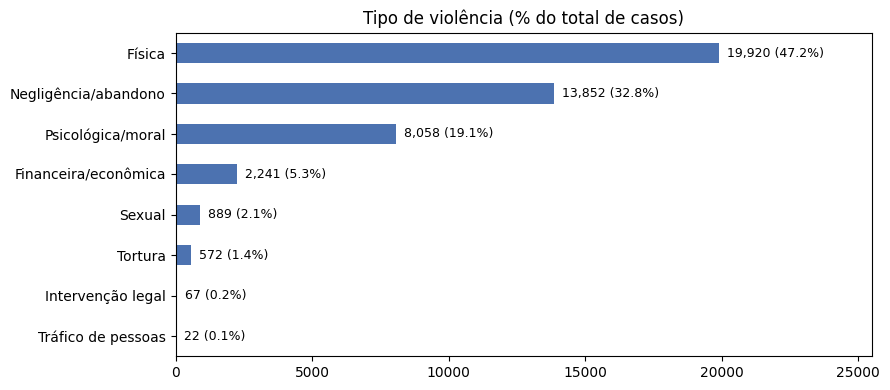

In [131]:
# 5. Tipo de violência

tipos = {
    "Física": "VIOL_FISIC",
    "Psicológica/moral": "VIOL_PSICO",
    "Negligência/abandono": "VIOL_NEGLI",
    "Financeira/econômica": "VIOL_FINAN",
    "Sexual": "VIOL_SEXU",
    "Tortura": "VIOL_TORT",
    "Tráfico de pessoas": "VIOL_TRAF",
    "Intervenção legal": "VIOL_LEGAL",
}

counting = pd.Series({
    rotulo: (elderly[col].map(normalize_code) == "1").sum()
    for rotulo, col in tipos.items() if col in elderly.columns
}).sort_values()

percentage = counting / len(elderly) * 100

graph = counting.plot(kind="barh", figsize=(9, 4), color="#4C72B0",
                   title="Tipo de violência (% do total de casos)")

for i, (v, p) in enumerate(zip(counting, percentage)):
    graph.text(v, i, f"  {v:,} ({p:.1f}%)", va="center", fontsize=9)

graph.set_xlim(0, counting.max() * 1.28)
plt.tight_layout()



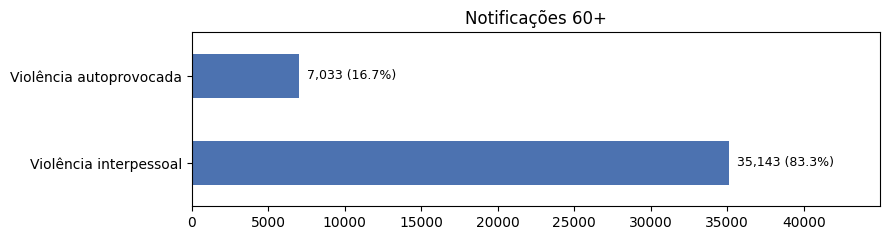

In [132]:
# 6. Dados sobre violência interpessoal e autoprovocada
selfharm = (elderly["REL_PROPRI"].map(normalize_code) == "1") | \
            (elderly["LES_AUTOP"].map(normalize_code) == "1")

counting = pd.Series({
    "Violência interpessoal": (~selfharm).sum(),
    "Violência autoprovocada": selfharm.sum(),
})
percentage = counting / len(elderly) * 100

graph = counting.plot(kind="barh", figsize=(9, 2.5), color="#4C72B0",
                      title="Notificações 60+")

for i, (v, p) in enumerate(zip(counting, percentage)):
    graph.text(v, i, f"  {v:,} ({p:.1f}%)", va="center", fontsize=9)

graph.set_xlim(0, counting.max() * 1.28)
plt.tight_layout()

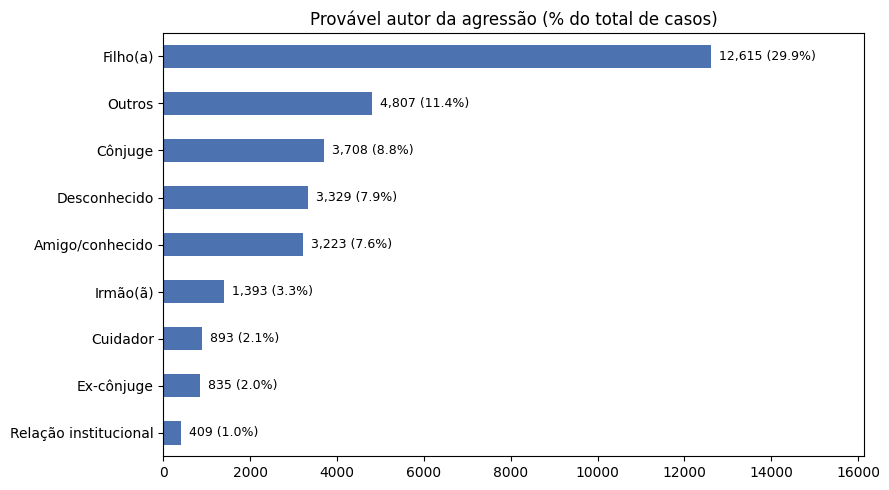

In [133]:
# 7. Provável autor da agressão

autores = {
    "Filho(a)": "REL_FILHO",
    "Cônjuge": "REL_CONJ",
    "Ex-cônjuge": "REL_EXCON",
    "Cuidador": "REL_CUIDA",
    "Irmão(ã)": "REL_IRMAO",
    "Amigo/conhecido": "REL_CONHEC",
    "Desconhecido": "REL_DESCO",
    "Relação institucional": "REL_INST",
    "Outros": "REL_OUTROS",
}

counting = pd.Series({
    rotulo: (elderly[col].map(normalize_code) == "1").sum()
    for rotulo, col in autores.items() if col in elderly.columns
}).sort_values()

percentage = counting / len(elderly) * 100

graph = counting.plot(kind="barh", figsize=(9, 5), color="#4C72B0",
                   title="Provável autor da agressão (% do total de casos)")

for i, (v, p) in enumerate(zip(counting, percentage)):
    graph.text(v, i, f"  {v:,} ({p:.1f}%)", va="center", fontsize=9)

graph.set_xlim(0, counting.max() * 1.28)
plt.tight_layout()

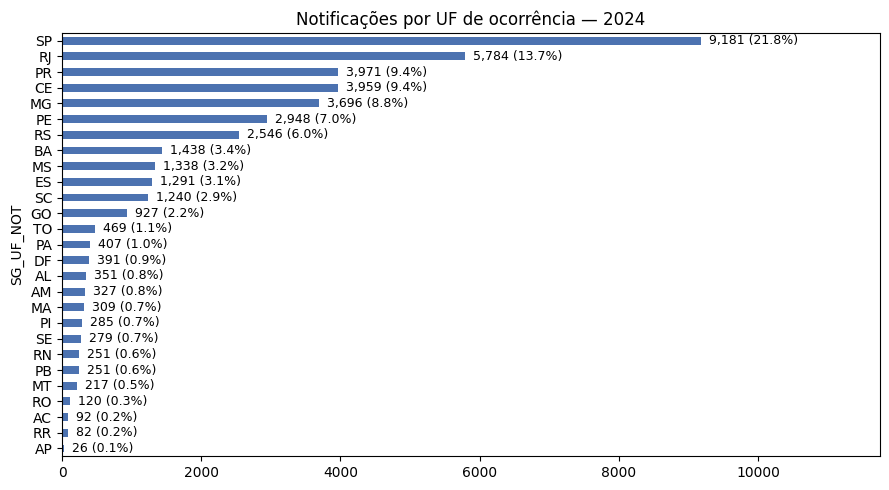

In [125]:
# 8. Distribuição por UF

counting = elderly["SG_UF_NOT"].value_counts().sort_values()
percentage = counting / len(elderly) * 100

graph = counting.plot(kind="barh", figsize=(9, 5), color="#4C72B0",
                   title=f"Notificações por UF de notificação — {YEAR}")

for i, (v, p) in enumerate(zip(counting, percentage)):
    graph.text(v, i, f"  {v:,} ({p:.1f}%)", va="center", fontsize=9)

graph.set_xlim(0, counting.max() * 1.28)
plt.tight_layout()